<a href="https://colab.research.google.com/github/AkshayKulkarni1904/Python/blob/main/notebooks/day_29_30_31_multiLinear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression**

1. Simple Linear Regression - 1 Input and 1 Output
2. Multi Linear Regression- Many Inputs and 1 output

# **Multi Linear Regression- Many Inputs and 1 output**

In [1]:
import pandas as pd

car = pd.read_csv('/content/mtcars.csv')
car[:2]

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.9,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.9,2.875,17.02,0,1,4,4


In [2]:
car.shape

(32, 11)

In [3]:
car['cyl'].value_counts()

,count
cyl,
8,14
4,11
6,7


In [4]:
# Data Preprocessing
# Missing values - isna()
# Noise/Outliers - boxplot

In [5]:
# Missing values - isna()
car.isna().sum()

,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0
gear,0


From above table we can conclude we dont have any missing values present in the available columns

<Axes: >

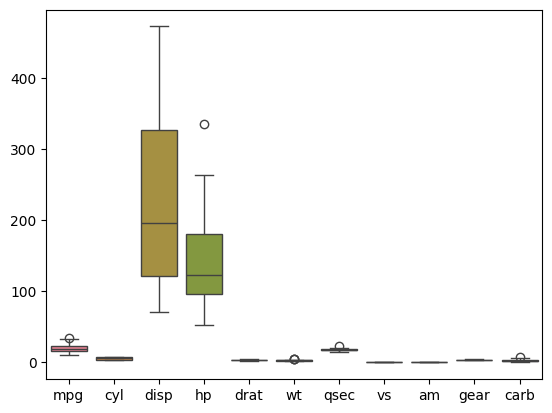

In [6]:
import seaborn as sns

sns.boxplot(data=car)

In [7]:
car.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

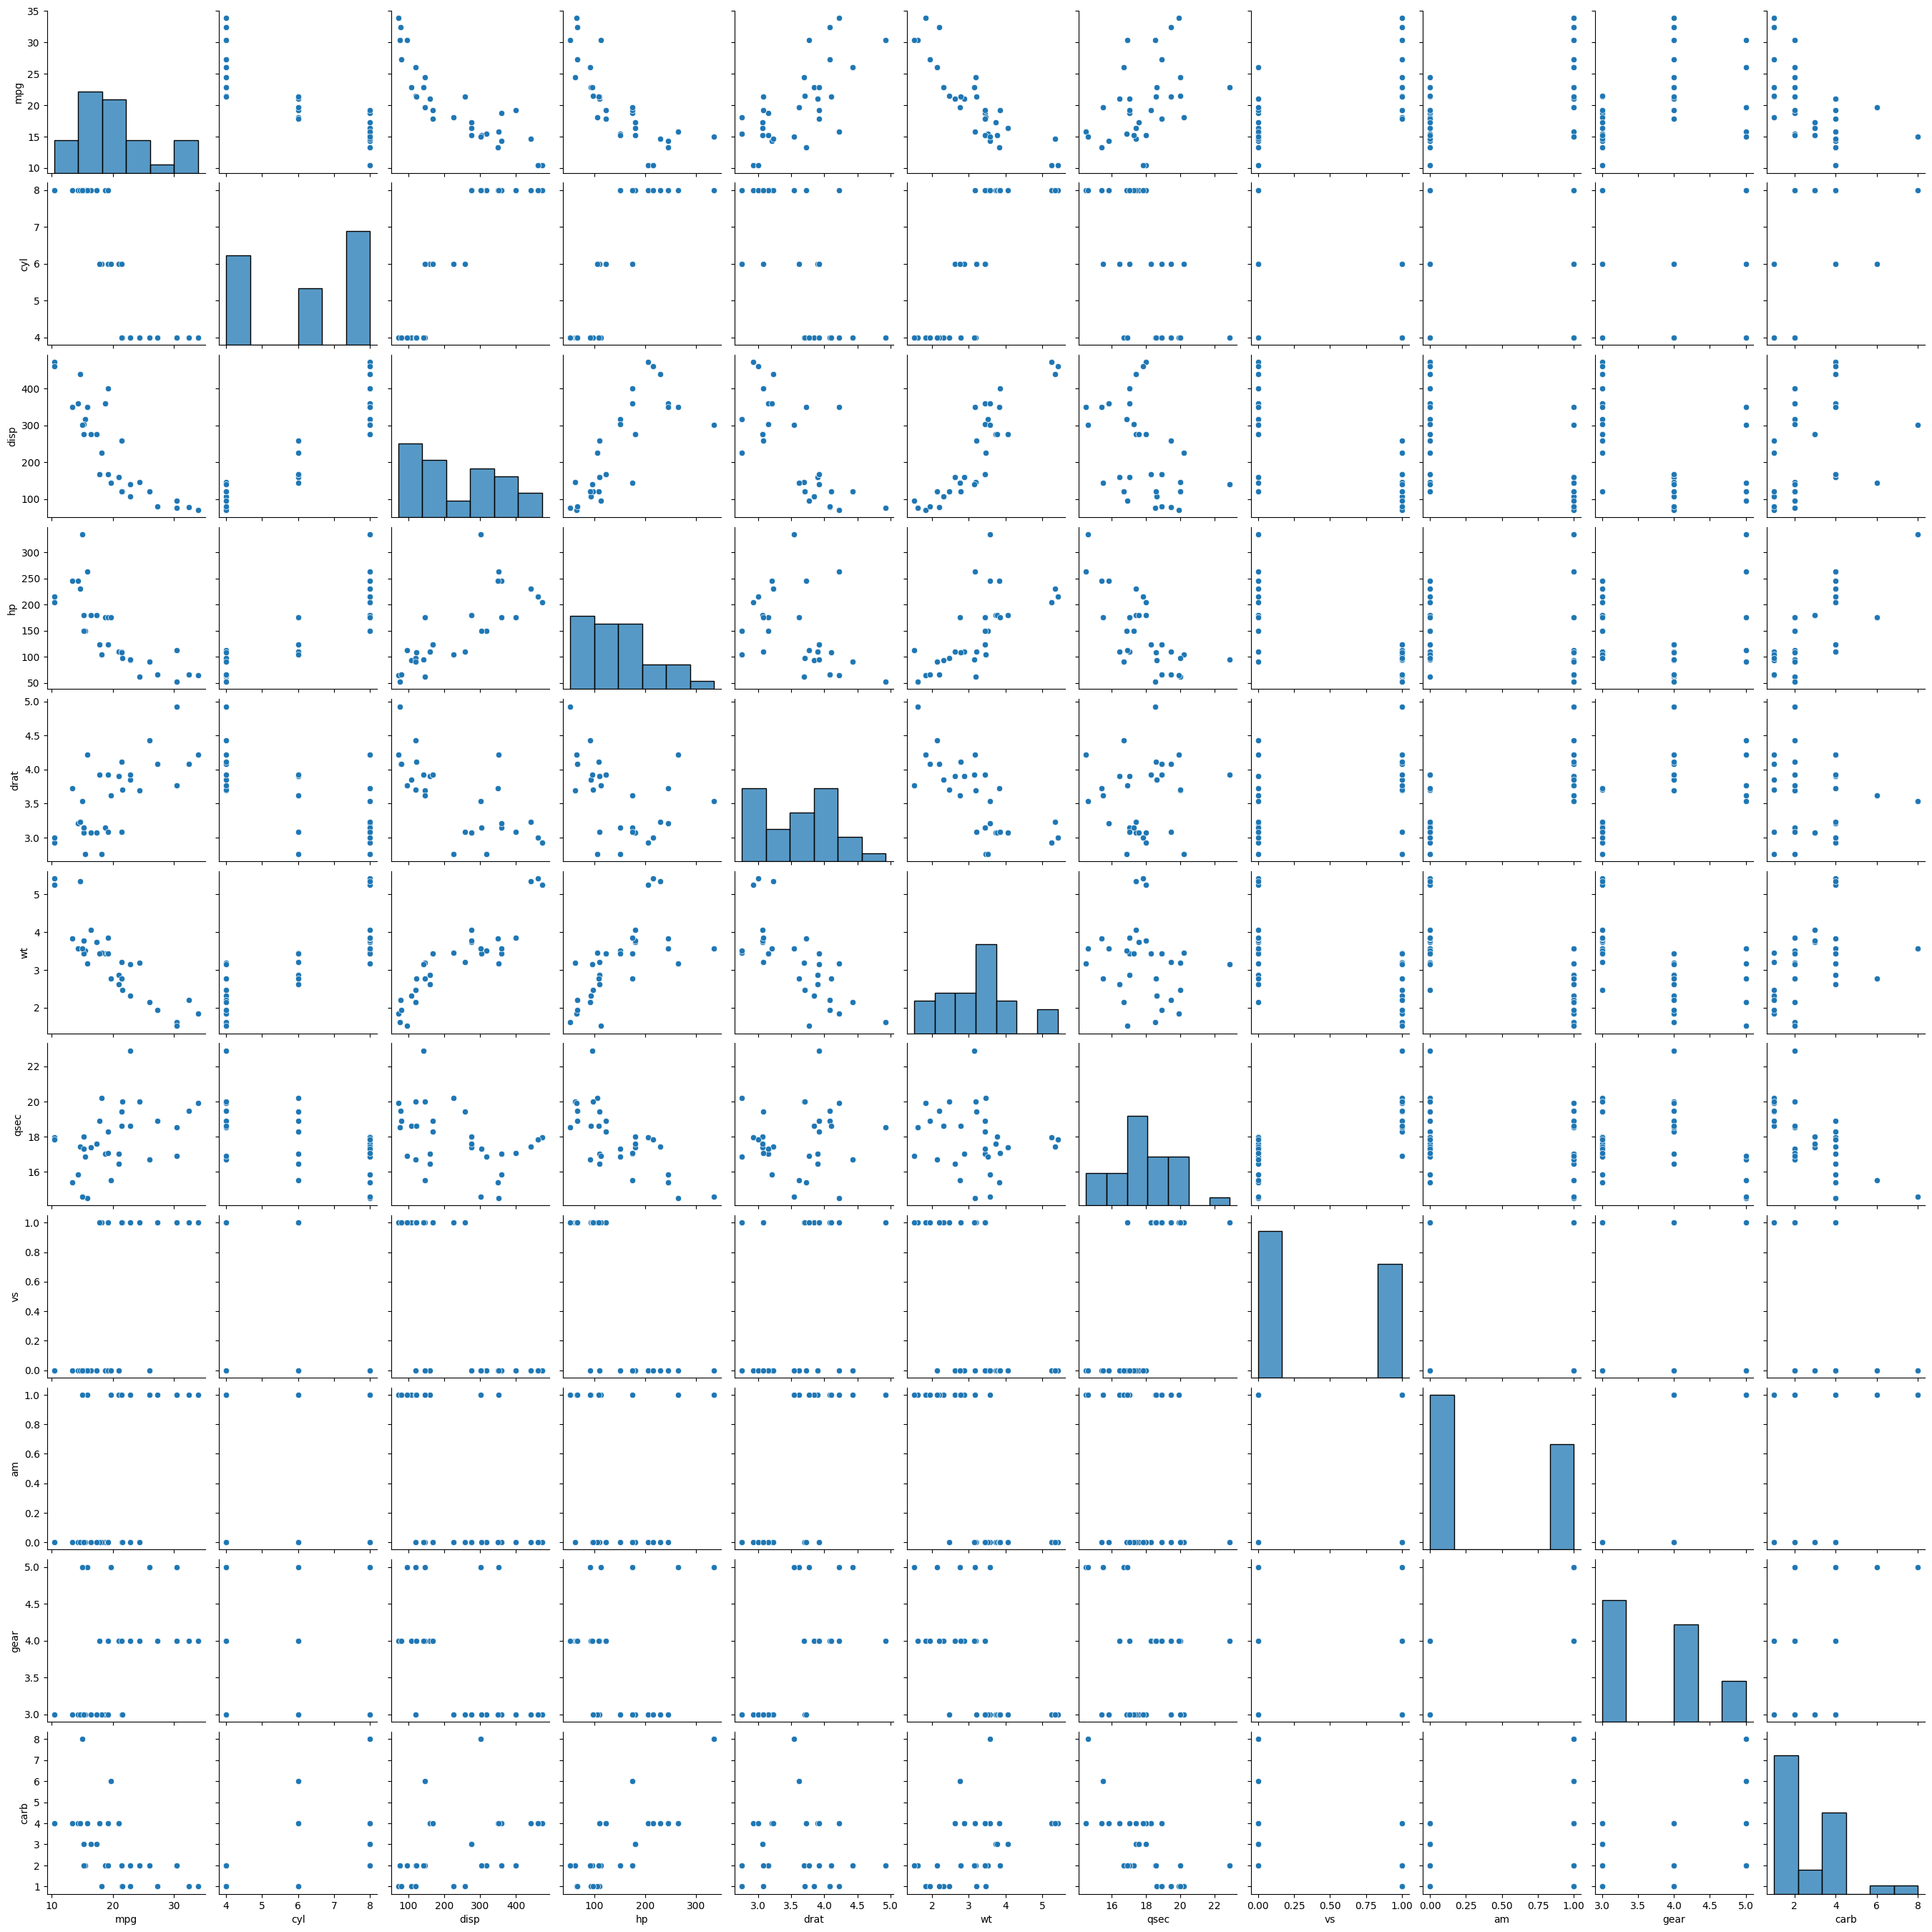

In [8]:
# matrix plot
sns.pairplot(data=car)

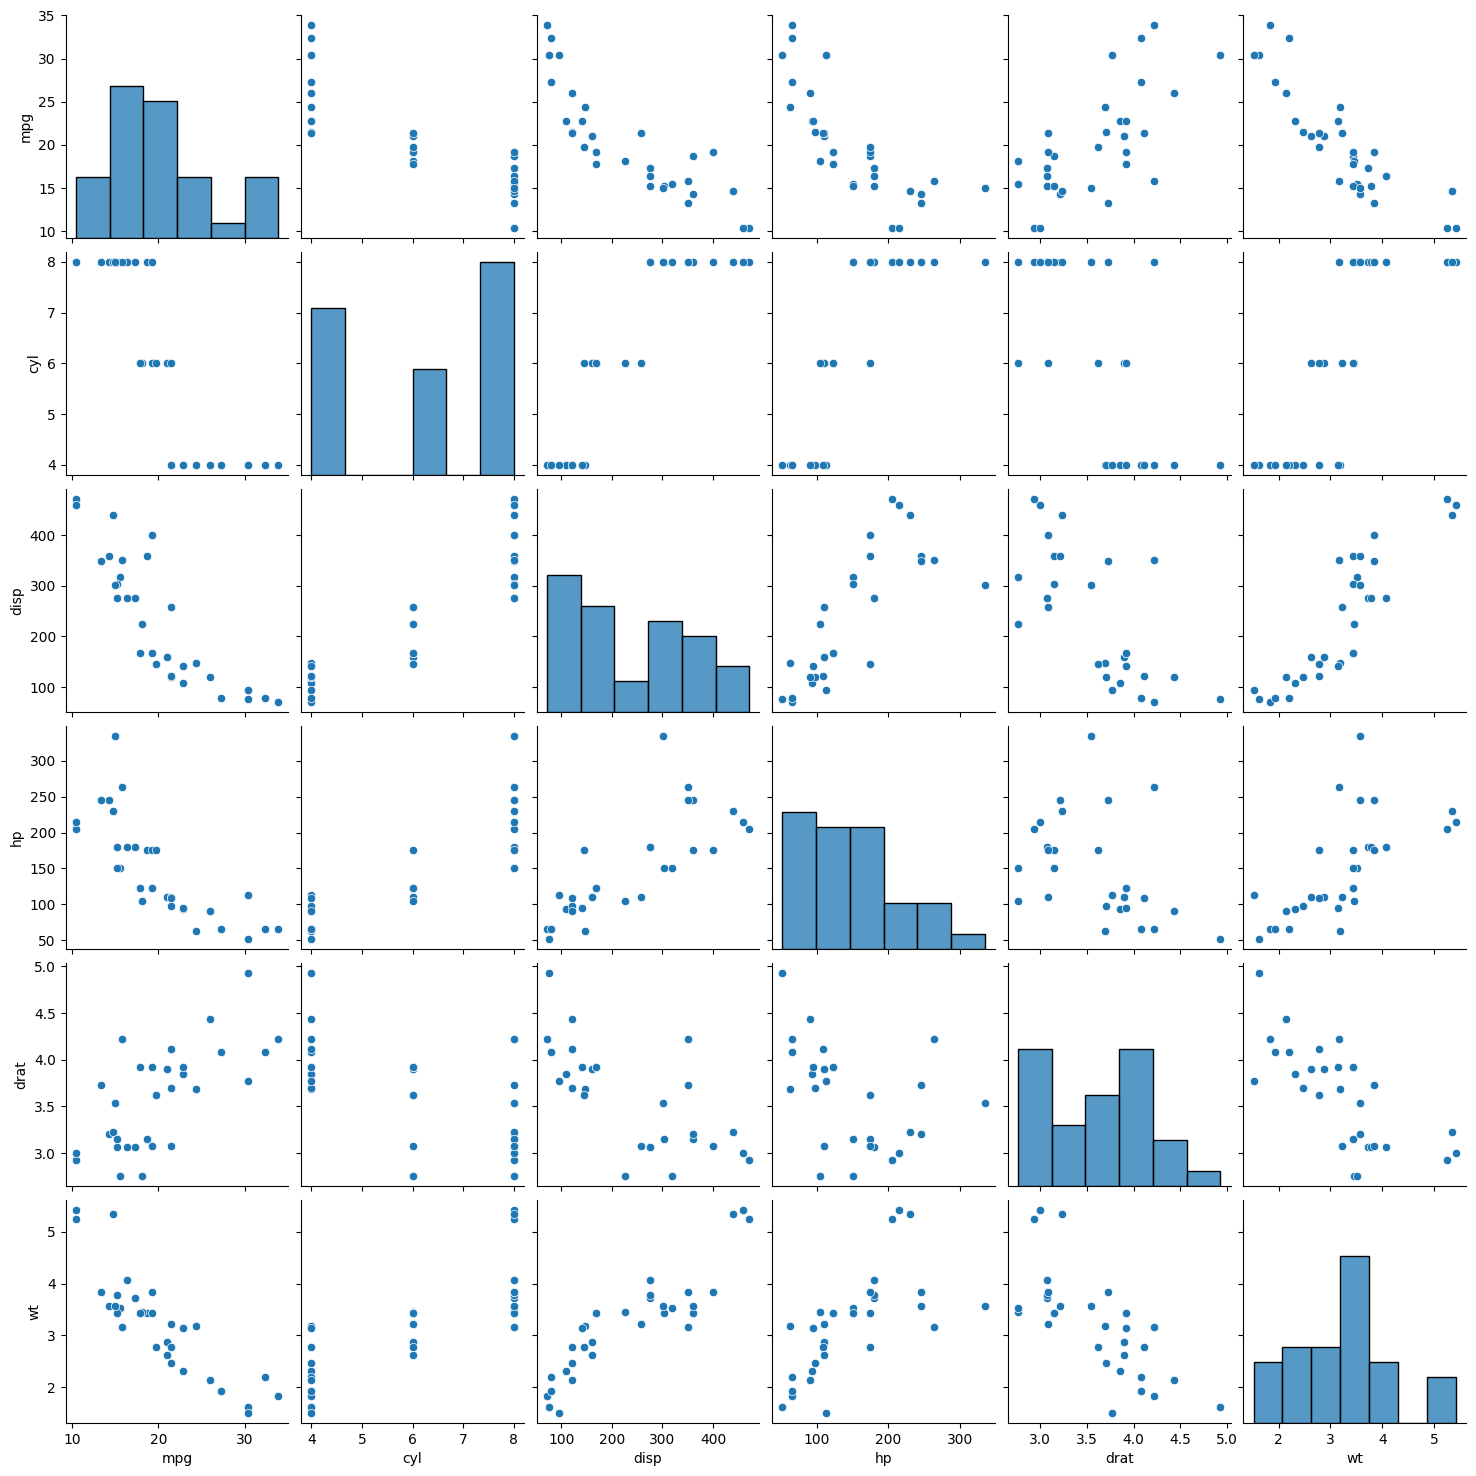

In [9]:
sns.pairplot(data=car[['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt']])

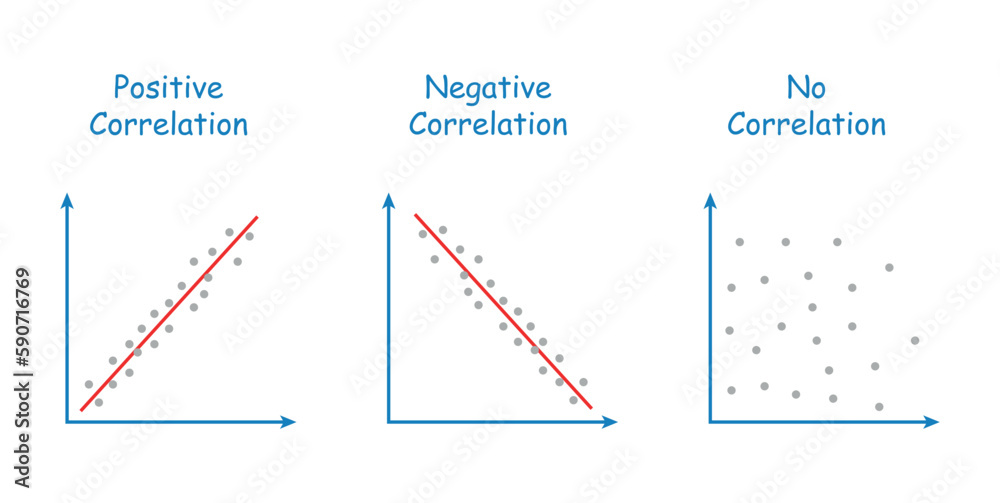

In [10]:
# for Linear regrression algorithms always check correlation

car.corr().style.background_gradient('Reds')

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.776168,0.681172,-0.867659,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.776168,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,0.681172,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.867659,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,0.418684,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073


In [11]:
# Prepare Data
X = car[['cyl','disp','wt','hp']]

y = car['mpg']

# **Problem Statememnt: Build a ML model to predict the Milage per gallon on the basis of cyl, disp, hp, wt**

In [55]:
# import algorithm

from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [57]:
# select first 5 records for testing
test_data = X.head()
test_data

,cyl,disp,wt,hp
0,6,160.0,2.620,110
1,6,160.0,2.875,110
2,4,108.0,2.320,93
3,6,258.0,3.215,110
4,8,360.0,3.440,175


In [58]:
# now use above test data for prediction

y_pred = model.predict(test_data)
y_pred #predicted

array([22.56804806, 21.58530266, 26.05685052, 21.41170091, 17.80606112])

In [59]:
y.head().values  # actual

array([21. , 21. , 22.8, 21.4, 18.7])

In [60]:
21. - 22.57   # error

-1.5700000000000003

In [61]:
model.score(X,y)*100

84.86347934212336

# ***Data Splitting***

To split the data we can go with different strategries

- 80 / 20 [ Training / Testing ]

- 70 / 30

- 75 / 25 **[Default selection]**

In [62]:
X[:2]

,cyl,disp,wt,hp
0,6,160.0,2.620,110
1,6,160.0,2.875,110


In [63]:
y[:2]

,mpg
0,21.0
1,21.0


In [64]:
#Split data
from sklearn.model_selection import train_test_split

In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2) #80|20

In [66]:
X_train[:2]

,cyl,disp,wt,hp
10,6,167.6,3.44,123
31,4,121.0,2.78,109


In [67]:
# Import algorithm
from sklearn.linear_model import LinearRegression

# Train model on training data
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [68]:
model.score(X_train,y_train),model.score(X_test,y_test)

(0.852506801133571, 0.798193165051617)

In [69]:
y_pred = model.predict(X_test)
y_pred  # predicted mgp

array([17.33664388, 26.46941222, 22.65463643, 27.59196792, 21.4771117 ,
       18.05838732, 19.07122392])

In [70]:
y_test.values # actual mgp

array([15.8, 26. , 22.8, 33.9, 21. , 15.2, 19.2])

In [71]:
model.score(X_test,y_test)


0.798193165051617

# ***Regression Metrix***

Also called Cost function/Loss function Performance metrix/measur

In [72]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [73]:
# MAE
mean_absolute_error(y_test,y_pred)

1.7033895502815153

In [74]:
# error = actu0al-predected

In [75]:
mean_squared_error(y_test,y_pred)

7.258374077067983

In [76]:
y_test.values

array([15.8, 26. , 22.8, 33.9, 21. , 15.2, 19.2])

In [77]:
y_pred

array([17.33664388, 26.46941222, 22.65463643, 27.59196792, 21.4771117 ,
       18.05838732, 19.07122392])

In [78]:
# Check score of model
r2_score(y_test,y_pred)

0.798193165051617

In [79]:
X_train[:5]

,cyl,disp,wt,hp
10,6,167.6,3.440,123
31,4,121.0,2.780,109
30,8,301.0,3.570,335
27,4,95.1,1.513,113
2,4,108.0,2.320,93


### Assume this model is good model
### Deployment
### Serilization Process --> Conver Python code to object / byte code

In [80]:
# Perform pickling (serelization process)
import pickle

pickle.dump(model,open('model.pkl','wb'))